# SPEIbase NetCDF → Annual Ground-Truth Dataset Extraction

## 1. Objective
This notebook demonstrates the end-to-end extraction, validation, and annual aggregation of the historical Standardized Precipitation-Evapotranspiration Index (**SPEI-1**) from the global **SPEIbase NetCDF** dataset for the **Debrebirkan Selassie** site in Ethiopia.

### Target Location
- **Site**: Debrebirkan Selassie, Ethiopia
- **Latitude**: $9.63^\circ\text{ N}$
- **Longitude**: $39.53^\circ\text{ E}$

### Purpose
To generate a validated, temporally consistent annual climate ground-truth series (`spei_debrebirkan.csv`) that serves as the target signal for the downstream Random Forest drought classification model.


## 2. Environment and Package Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Ensure project root is in sys.path
PROJECT_ROOT = Path("..").resolve() if Path("..").resolve().name == "Fradscr" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from treering.spei import (
    load_netcdf,
    inspect_dataset,
    resolve_spei_variable,
    validate_coordinates,
    extract_point_series,
    validate_time_axis,
    aggregate_annual_spei,
    to_annual_dataframe,
    export_annual_spei_csv,
    export_provenance_json,
    check_downstream_compatibility,
    extract_annual_spei,
    DEFAULT_TARGET_LAT,
    DEFAULT_TARGET_LON,
)

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

print(f"Xarray version: {xr.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")
print(f"Project root:   {PROJECT_ROOT}")


Xarray version: 2026.7.0
Pandas version: 3.0.5
NumPy version:  2.5.2
Project root:   /home/hezekiah/Documents/Egate_AIML/Fradscr


## 3. Load NetCDF Dataset

In [2]:
NC_PATH = PROJECT_ROOT / "data" / "spei01.nc"
print(f"Opening dataset from: {NC_PATH}")
ds = load_netcdf(NC_PATH)
print("NetCDF dataset successfully loaded.")


Opening dataset from: /home/hezekiah/Documents/Egate_AIML/Fradscr/data/spei01.nc
NetCDF dataset successfully loaded.


## 4. Inspect Dataset Metadata

In [3]:
info = inspect_dataset(ds)
print("=== Dataset Dimensions ===")
for dim, sz in info["dimensions"].items():
    print(f"  {dim}: {sz}")

print("\n=== Coordinates ===")
for coord in info["coordinates"]:
    c = ds[coord]
    print(f"  {coord}: dtype={c.dtype}, shape={c.shape}")

print("\n=== Data Variables ===")
for var in info["data_vars"]:
    v = ds[var]
    print(f"  {var}: dtype={v.dtype}, shape={v.shape}")

print("\n=== Selected Global Attributes ===")
for k in ["title", "version", "institution", "source", "reference"]:
    if k in ds.attrs:
        print(f"  {k}: {ds.attrs[k]}")


=== Dataset Dimensions ===
  time: 1488
  lat: 360
  lon: 720

=== Coordinates ===
  lon: dtype=float64, shape=(720,)
  lat: dtype=float64, shape=(360,)
  time: dtype=datetime64[ns], shape=(1488,)

=== Data Variables ===
  spei: dtype=float32, shape=(1488, 360, 720)
  crs: dtype=int32, shape=()

=== Selected Global Attributes ===
  title: Global 1-month SPEI, z-values, 0.5 degree
  version: 2.11.0
  institution: Consejo Superior de Investigaciones Científicas, CSIC
  source: http://sac.csic.es/spei
  reference: Beguería S., Vicente-Serrano S., Reig F., Latorre B. (2014) Standardized precipitation evapotranspiration index (SPEI) revisited: Parameter fitting, evapotranspiration models, tools, datasets and drought monitoring. International Journal of Climatology 34, 3001-3023.


## 5. Identify SPEI Variable

In [4]:
var_name = resolve_spei_variable(ds)
spei_var = ds[var_name]
print(f"Verified SPEI variable: '{var_name}'")
print(f"Dimensions: {spei_var.dims}")
print(f"Shape:      {spei_var.shape}")
print(f"Attributes: {spei_var.attrs}")


Verified SPEI variable: 'spei'
Dimensions: ('time', 'lat', 'lon')
Shape:      (1488, 360, 720)
Attributes: {'units': '1', 'long_name': 'Standardized Precipitation-Evapotranspiration Index', 'grid_mapping': 'crs'}


## 6. Inspect Spatial Coordinates

In [5]:
lat_name, lon_name, time_name = validate_coordinates(ds)
print(f"Latitude coordinate:  '{lat_name}' (min={float(ds[lat_name].min()):.2f}, max={float(ds[lat_name].max()):.2f})")
print(f"Longitude coordinate: '{lon_name}' (min={float(ds[lon_name].min()):.2f}, max={float(ds[lon_name].max()):.2f})")
print(f"Time coordinate:      '{time_name}' (start={str(ds[time_name].values[0])[:10]}, end={str(ds[time_name].values[-1])[:10]})")


Latitude coordinate:  'lat' (min=-89.75, max=89.75)
Longitude coordinate: 'lon' (min=-179.75, max=179.75)
Time coordinate:      'time' (start=1901-01-16, end=2024-12-16)


## 7. Extract Debrebirkan Selassie Grid Cell

In [6]:
target_lat = DEFAULT_TARGET_LAT
target_lon = DEFAULT_TARGET_LON

point_da, grid_meta = extract_point_series(ds, lat=target_lat, lon=target_lon)
print("Grid cell extraction complete.")


Grid cell extraction complete.


## 8. Validate Selected Grid Cell

In [7]:
grid_df = pd.DataFrame([grid_meta.to_dict()])
print("=== Grid Cell Selection & Offset Report ===")
print(f"Requested Coordinates: ({grid_meta.requested_lat:.4f} N, {grid_meta.requested_lon:.4f} E)")
print(f"Selected Grid Cell:    ({grid_meta.selected_lat:.4f} N, {grid_meta.selected_lon:.4f} E)")
print(f"Latitude Offset:       {grid_meta.lat_offset:+.4f} deg")
print(f"Longitude Offset:      {grid_meta.lon_offset:+.4f} deg")
print(f"Spatial Distance:      {grid_meta.spatial_distance_km:.2f} km")


=== Grid Cell Selection & Offset Report ===
Requested Coordinates: (9.6300 N, 39.5300 E)
Selected Grid Cell:    (9.7500 N, 39.7500 E)
Latitude Offset:       +0.1200 deg
Longitude Offset:      +0.2200 deg
Spatial Distance:      27.56 km


## 9. Inspect Time Coordinate

In [8]:
time_meta = validate_time_axis(point_da)
print("=== Temporal Metadata ===")
print(f"Start Date:         {time_meta.start_date[:10]}")
print(f"End Date:           {time_meta.end_date[:10]}")
print(f"Total Months:       {time_meta.total_months}")
print(f"Total Years:        {time_meta.total_years}")
print(f"Complete Years:     {time_meta.complete_years}")
print(f"Incomplete Years:   {time_meta.incomplete_years}")
print(f"Calendar:           {time_meta.calendar}")
print(f"Temporal Frequency: {time_meta.time_frequency}")


=== Temporal Metadata ===
Start Date:         1901-01-16
End Date:           2024-12-16
Total Months:       1488
Total Years:        124
Complete Years:     124
Incomplete Years:   []
Calendar:           standard
Temporal Frequency: monthly


## 10. Validate Monthly Coverage

In [9]:
monthly_s = point_da.to_series()
print(f"Total monthly observations: {len(monthly_s)}")
print(f"NaN count:                  {monthly_s.isna().sum()}")
print(f"Infinite count:             {np.isinf(monthly_s.values).sum()}")
print(f"Monthly Min:                {monthly_s.min():.4f}")
print(f"Monthly Max:                {monthly_s.max():.4f}")
print(f"Monthly Mean:               {monthly_s.mean():.4f}")
print(f"Monthly Std:                {monthly_s.std():.4f}")


Total monthly observations: 1488
NaN count:                  0
Infinite count:             0
Monthly Min:                -3.6817
Monthly Max:                3.3068
Monthly Mean:               0.0060
Monthly Std:                0.9963


## 11. Aggregate to Annual SPEI (Complete-Year Policy)

In [10]:
annual_s, dropped_years = aggregate_annual_spei(
    point_da,
    require_full_year=True,
    min_months=12,
)
print(f"Successfully aggregated {len(annual_s)} complete calendar years.")
print(f"Dropped incomplete years: {dropped_years}")


Successfully aggregated 124 complete calendar years.
Dropped incomplete years: []


## 12. Validate Complete Years

In [11]:
print(f"Annual Series Span: {annual_s.index.min()} - {annual_s.index.max()}")
print(f"Expected Number of Years: {annual_s.index.max() - annual_s.index.min() + 1}")
print(f"Actual Complete Years:    {len(annual_s)}")
assert len(annual_s) == (annual_s.index.max() - annual_s.index.min() + 1), "Temporal discontinuity detected!"
print("Verification Passed: 100% continuous calendar years with no missing years.")


Annual Series Span: 1901 - 2024
Expected Number of Years: 124
Actual Complete Years:    124
Verification Passed: 100% continuous calendar years with no missing years.


## 13. Convert to Production DataFrame

In [12]:
annual_df = to_annual_dataframe(annual_s)
print(f"DataFrame shape:   {annual_df.shape}")
print(f"Columns:           {list(annual_df.columns)}")
print(f"Year dtype:        {annual_df['year'].dtype}")
print(f"SPEI dtype:        {annual_df['spei'].dtype}")


DataFrame shape:   (124, 2)
Columns:           ['year', 'spei']
Year dtype:        int64
SPEI dtype:        float64


## 14. Inspect First and Last Rows

In [13]:
print("=== First 5 Rows ===")
print(annual_df.head(5).to_string(index=False))

print("\n=== Last 5 Rows ===")
print(annual_df.tail(5).to_string(index=False))


=== First 5 Rows ===
 year      spei
 1901  0.247951
 1902 -0.229128
 1903  0.274068
 1904 -0.223645
 1905 -0.253220

=== Last 5 Rows ===
 year      spei
 2020  0.606446
 2021 -0.204965
 2022 -0.067814
 2023  0.168849
 2024  0.680732


## 15. Export Clean CSV Dataset

In [14]:
OUTPUT_CSV = PROJECT_ROOT / "results" / "spei_debrebirkan.csv"
saved_path = export_annual_spei_csv(annual_df, OUTPUT_CSV, overwrite=True)
print(f"Exported to: {saved_path}")


Exported to: /home/hezekiah/Documents/Egate_AIML/Fradscr/results/spei_debrebirkan.csv


## 16. Re-read CSV From Disk & Verify

In [15]:
reloaded_df = pd.read_csv(OUTPUT_CSV)
print("=== Re-read CSV Verification ===")
print(f"Rows loaded:       {len(reloaded_df)}")
print(f"Columns:           {list(reloaded_df.columns)}")
print(f"Any NaN values:    {reloaded_df['spei'].isna().any()}")
print(f"Any duplicate yrs: {reloaded_df['year'].duplicated().any()}")
print(f"Year range:        {reloaded_df['year'].min()}–{reloaded_df['year'].max()}")


=== Re-read CSV Verification ===
Rows loaded:       124
Columns:           ['year', 'spei']
Any NaN values:    False
Any duplicate yrs: False
Year range:        1901–2024


## 17. Scientific Visualization of Historical SPEI

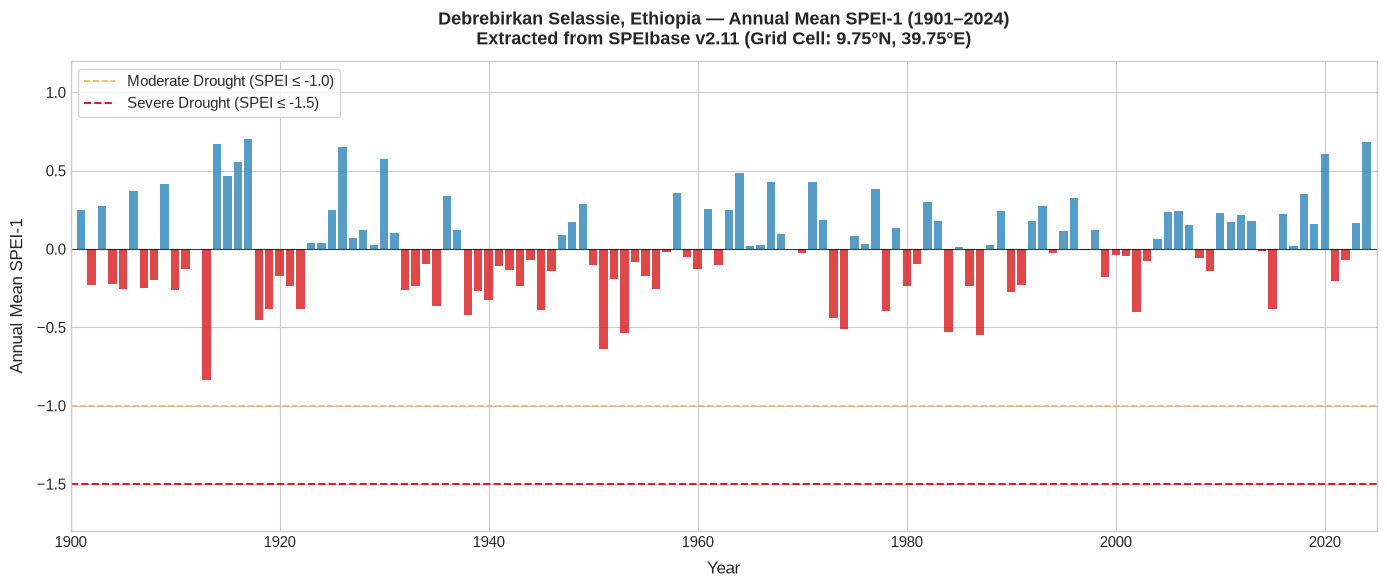

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

years = annual_df["year"].values
spei = annual_df["spei"].values

# Color bars based on wet vs dry
colors = np.where(spei >= 0, "#2b83ba", "#d7191c")
bars = ax.bar(years, spei, color=colors, width=0.8, alpha=0.8, edgecolor="none")

# Reference threshold lines
ax.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.7)
ax.axhline(-1.0, color="#fdae61", linestyle="--", linewidth=1.2, label="Moderate Drought (SPEI ≤ -1.0)")
ax.axhline(-1.5, color="#d7191c", linestyle="--", linewidth=1.4, label="Severe Drought (SPEI ≤ -1.5)")

ax.set_title(
    f"Debrebirkan Selassie, Ethiopia — Annual Mean SPEI-1 (1901–2024)\n"
    f"Extracted from SPEIbase v2.11 (Grid Cell: {grid_meta.selected_lat}°N, {grid_meta.selected_lon}°E)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Year", fontsize=12, labelpad=8)
ax.set_ylabel("Annual Mean SPEI-1", fontsize=12, labelpad=8)
ax.set_xlim(years.min() - 1, years.max() + 1)
ax.set_ylim(min(spei.min() - 0.2, -1.8), max(spei.max() + 0.2, 1.2))
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()


## 18. Downstream RWI/Solar Merge Compatibility

In [17]:
LAGGED_CSV = PROJECT_ROOT / "results" / "processed_lagged_data.csv"
compat = check_downstream_compatibility(annual_df, LAGGED_CSV)

print("=== Downstream Dataset Merge Report ===")
print(f"Compatible:                   {compat.get('compatible')}")
print(f"RWI/Solar Total Rows:         {compat.get('rwi_total_rows')}")
print(f"RWI Unique Years:             {compat.get('rwi_unique_years')} (Range: {compat.get('rwi_year_range')})")
print(f"SPEI Unique Years:            {compat.get('spei_unique_years')} (Range: {compat.get('spei_year_range')})")
print(f"Overlapping Years Count:      {compat.get('overlapping_years_count')}")
print(f"Overlap Temporal Span:        {compat.get('overlap_start_year')} – {compat.get('overlap_end_year')}")
print(f"Merged Dataset Rows:          {compat.get('overlapping_rows')}")
print(f"RWI Years Missing SPEI (<1901): {compat.get('rwi_years_missing_spei_count')} years")


=== Downstream Dataset Merge Report ===
Compatible:                   True
RWI/Solar Total Rows:         1451
RWI Unique Years:             146 (Range: [1869, 2014])
SPEI Unique Years:            124 (Range: [1901, 2024])
Overlapping Years Count:      114
Overlap Temporal Span:        1901 – 2014
Merged Dataset Rows:          1338
RWI Years Missing SPEI (<1901): 32 years


## 19. Extraction Pipeline Summary

In [18]:
summary = {
    "Target Site": "Debrebirkan Selassie, Ethiopia",
    "Requested Coordinates": f"({target_lat}°N, {target_lon}°E)",
    "Selected Grid Cell": f"({grid_meta.selected_lat}°N, {grid_meta.selected_lon}°E)",
    "Spatial Distance": f"{grid_meta.spatial_distance_km:.2f} km",
    "Source Dataset": "SPEIbase v2.11 (Global 0.5° SPEI-1)",
    "Temporal Range": f"{annual_df['year'].min()} – {annual_df['year'].max()} ({len(annual_df)} complete years)",
    "Incomplete Years Dropped": len(dropped_years),
    "Mean Annual SPEI": f"{annual_df['spei'].mean():.4f}",
    "Std Annual SPEI": f"{annual_df['spei'].std():.4f}",
    "Min Annual SPEI": f"{annual_df['spei'].min():.4f} (Year {annual_df.loc[annual_df['spei'].idxmin(), 'year']})",
    "Max Annual SPEI": f"{annual_df['spei'].max():.4f} (Year {annual_df.loc[annual_df['spei'].idxmax(), 'year']})",
    "Output CSV": str(saved_path),
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Attribute", "Value"])
print(summary_df.to_string(index=False))


               Attribute                                                                    Value
             Target Site                                           Debrebirkan Selassie, Ethiopia
   Requested Coordinates                                                        (9.63°N, 39.53°E)
      Selected Grid Cell                                                        (9.75°N, 39.75°E)
        Spatial Distance                                                                 27.56 km
          Source Dataset                                      SPEIbase v2.11 (Global 0.5° SPEI-1)
          Temporal Range                                         1901 – 2024 (124 complete years)
Incomplete Years Dropped                                                                        0
        Mean Annual SPEI                                                                   0.0060
         Std Annual SPEI                                                                   0.3009
         Min Annual 